In [ ]:
!pip install snntorch joblib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 2.2 MB/s eta 0:00:00


In [ ]:
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import snntorch as snn
import torch
from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from snntorch import surrogate
from torch import nn
from torch.utils.data import DataLoader, Dataset

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will use CPU.")

Device: cpu
GPU not available. Training will use CPU.


In [ ]:
uploaded = files.upload()

Saving Agrovision Cotoon SNN Dataset.csv to Agrovision Cotoon SNN Dataset.csv


In [ ]:
file_name = "Agrovision Cotoon SNN Dataset.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (14980, 36)


,date,field_id,location,district,region,latitude,longitude,growth_stage,days_since_sowing,air_temperature_C,...,month,dataset,environmental_stress_score,environmental_stress_risk,temperature,light,AQI,ozone,stress_label,time_index
0,2019-06-01,NGP-COT-01,Nagpur City,Nagpur,"Vidarbha, Maharashtra",21.1458,79.0882,Sowing,0,38.8,...,6,Cotton prototype derived from Orange dataset,0.6080,High,38.8,815.89,76.90,0.04850,High,0
1,2019-06-02,NGP-COT-01,Nagpur City,Nagpur,"Vidarbha, Maharashtra",21.1458,79.0882,Sowing,0,39.4,...,6,Cotton prototype derived from Orange dataset,0.6358,High,39.4,840.52,91.01,0.04730,High,1
2,2019-06-03,NGP-COT-01,Nagpur City,Nagpur,"Vidarbha, Maharashtra",21.1458,79.0882,Sowing,1,39.9,...,6,Cotton prototype derived from Orange dataset,0.6750,High,39.9,800.26,85.19,0.04387,High,2
3,2019-06-04,NGP-COT-01,Nagpur City,Nagpur,"Vidarbha, Maharashtra",21.1458,79.0882,Sowing,2,39.3,...,6,Cotton prototype derived from Orange dataset,0.6734,High,39.3,833.67,96.19,0.04598,High,3
4,2019-06-05,NGP-COT-01,Nagpur City,Nagpur,"Vidarbha, Maharashtra",21.1458,79.0882,Sowing,3,40.6,...,6,Cotton prototype derived from Orange dataset,0.6587,High,40.6,839.53,80.58,0.05060,High,4


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
for i, column in enumerate(df.columns):
    print(i, ":", column)

Number of rows: 14980
Number of columns: 36

Columns:
0 : date
1 : field_id
2 : location
3 : district
4 : region
5 : latitude
6 : longitude
7 : growth_stage
8 : days_since_sowing
9 : air_temperature_C
10 : rainfall_mm
11 : humidity_percent
12 : soil_moisture
13 : soil_nitrogen
14 : soil_phosphorus
15 : soil_potassium
16 : NDVI
17 : EVI
18 : GNDVI
19 : SIF_740
20 : F687
21 : F760
22 : fluorescence_ratio
23 : chlorophyll_content
24 : leaf_area_index
25 : year
26 : month
27 : dataset
28 : environmental_stress_score
29 : environmental_stress_risk
30 : temperature
31 : light
32 : AQI
33 : ozone
34 : stress_label
35 : time_index


In [ ]:
print(df.dtypes)

date                           object
field_id                       object
location                       object
district                       object
region                         object
latitude                      float64
longitude                     float64
growth_stage                   object
days_since_sowing               int64
air_temperature_C             float64
rainfall_mm                   float64
humidity_percent              float64
soil_moisture                 float64
soil_nitrogen                   int64
soil_phosphorus               float64
soil_potassium                float64
NDVI                          float64
EVI                           float64
GNDVI                         float64
SIF_740                       float64
F687                          float64
F760                          float64
fluorescence_ratio            float64
chlorophyll_content           float64
leaf_area_index               float64
year                            int64
month       

In [ ]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

if missing.sum() == 0:
    print("\nNo missing values found.")

Missing values:
Series([], dtype: int64)

No missing values found.


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (14980, 36)


stress_label
Low         7181
High        4944
Moderate    2855
Name: count, dtype: int64


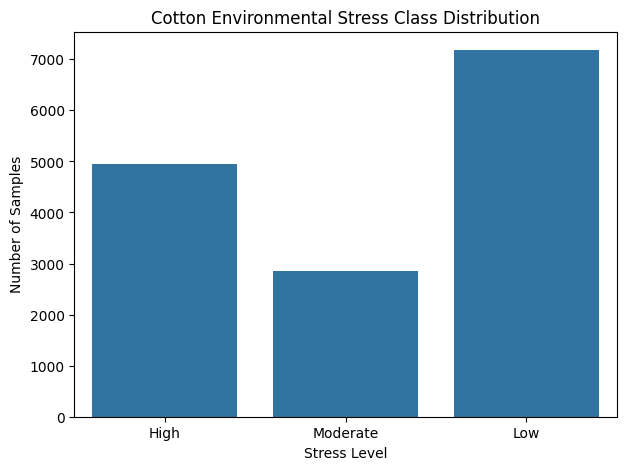

In [ ]:
print(df["stress_label"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="stress_label"
)

plt.title("Cotton Environmental Stress Class Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
print(
    df.groupby("stress_label")["environmental_stress_score"]
      .agg(["min", "max", "mean"])
)

                 min     max      mean
stress_label                          
High          0.2387  0.7695  0.320402
Low           0.0000  0.0000  0.000000
Moderate      0.0000  0.2386  0.126377


In [ ]:
print(
    pd.crosstab(
        df["environmental_stress_risk"],
        df["stress_label"]
    )
)

stress_label               High   Low  Moderate
environmental_stress_risk                      
High                       4944     0         0
Low                           0  7181         0
Moderate                      0     0      2855


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df["date_day"] = df["date"].dt.day
df["date_month"] = df["date"].dt.month
df["date_year"] = df["date"].dt.year

print(df[[
    "date",
    "date_day",
    "date_month",
    "date_year"
]].head())

        date  date_day  date_month  date_year
0 2019-06-01         1           6       2019
1 2019-06-02         2           6       2019
2 2019-06-03         3           6       2019
3 2019-06-04         4           6       2019
4 2019-06-05         5           6       2019


In [ ]:
df = df.sort_values("date").reset_index(drop=True)

print("Earliest date:", df["date"].min())
print("Latest date:", df["date"].max())

Earliest date: 2019-06-01 00:00:00
Latest date: 2025-12-31 00:00:00


Training


In [ ]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print("\nTraining period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation period:")
print(val_df["date"].min(), "to", val_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

Training samples: 10486
Validation samples: 2247
Testing samples: 2247

Training period:
2019-06-01 00:00:00 to 2023-12-10 00:00:00

Validation period:
2023-12-10 00:00:00 to 2024-12-21 00:00:00

Testing period:
2024-12-21 00:00:00 to 2025-12-31 00:00:00


In [ ]:
DROP_COLUMNS = [
    "date",
    "field_id",
    "location",
    "district",
    "region",
    "dataset",

    # Target leakage
    "environmental_stress_score",
    "environmental_stress_risk",

    # Target
    "stress_label",

    # Duplicate of air_temperature_C
    "temperature"
]

FEATURE_COLUMNS = [
    col for col in df.columns
    if col not in DROP_COLUMNS
]

print("Number of input features:", len(FEATURE_COLUMNS))

print("\nFeatures used by SNN:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

Number of input features: 29

Features used by SNN:
- latitude
- longitude
- growth_stage
- days_since_sowing
- air_temperature_C
- rainfall_mm
- humidity_percent
- soil_moisture
- soil_nitrogen
- soil_phosphorus
- soil_potassium
- NDVI
- EVI
- GNDVI
- SIF_740
- F687
- F760
- fluorescence_ratio
- chlorophyll_content
- leaf_area_index
- year
- month
- light
- AQI
- ozone
- time_index
- date_day
- date_month
- date_year


In [ ]:

categorical_features = ["growth_stage"]

numeric_features = [
    col for col in FEATURE_COLUMNS
    if col not in categorical_features
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features: 28
Categorical features: ['growth_stage']


In [ ]:
def prepare_features(data):

    data = data.copy()

    # Numeric data
    X_numeric = data[numeric_features].copy()

    # Categorical data
    X_categorical = pd.get_dummies(
        data[categorical_features],
        columns=categorical_features,
        dtype=float
    )

    return X_numeric, X_categorical

In [ ]:
X_train_numeric, X_train_cat = prepare_features(train_df)
X_val_numeric, X_val_cat = prepare_features(val_df)
X_test_numeric, X_test_cat = prepare_features(test_df)

In [ ]:
X_train_cat, X_val_cat = X_train_cat.align(
    X_val_cat,
    join="left",
    axis=1,
    fill_value=0
)

X_train_cat, X_test_cat = X_train_cat.align(
    X_test_cat,
    join="left",
    axis=1,
    fill_value=0
)

print("Categorical columns:")
print(X_train_cat.columns.tolist())

Categorical columns:
['growth_stage_Boll_Development', 'growth_stage_Flowering', 'growth_stage_Maturity', 'growth_stage_Sowing', 'growth_stage_Vegetative']


In [ ]:
X_train = pd.concat(
    [X_train_numeric, X_train_cat],
    axis=1
)

X_val = pd.concat(
    [X_val_numeric, X_val_cat],
    axis=1
)

X_test = pd.concat(
    [X_test_numeric, X_test_cat],
    axis=1
)

print("Final training shape:", X_train.shape)
print("Final validation shape:", X_val.shape)
print("Final testing shape:", X_test.shape)

Final training shape: (10486, 33)
Final validation shape: (2247, 33)
Final testing shape: (2247, 33)


In [ ]:
print("Infinite values in training:",
      np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())

print("Infinite values in validation:",
      np.isinf(X_val.select_dtypes(include=np.number)).sum().sum())

print("Infinite values in testing:",
      np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

Infinite values in training: 0
Infinite values in validation: 0
Infinite values in testing: 0


In [ ]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [ ]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df["stress_label"]
)

y_val = label_encoder.transform(
    val_df["stress_label"]
)

y_test = label_encoder.transform(
    test_df["stress_label"]
)

print("Classes:")
print(label_encoder.classes_)

Classes:
['High' 'Low' 'Moderate']


In [ ]:
for i, class_name in enumerate(label_encoder.classes_):
    print(
        i,
        "=", class_name,
        "| Train:",
        np.sum(y_train == i),
        "| Validation:",
        np.sum(y_val == i),
        "| Test:",
        np.sum(y_test == i)
    )

0 = High | Train: 3449 | Validation: 825 | Test: 670
1 = Low | Train: 5139 | Validation: 1005 | Test: 1037
2 = Moderate | Train: 1898 | Validation: 417 | Test: 540


In [ ]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([10486, 33])
torch.Size([10486])


In [ ]:
class CottonStressDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [ ]:
train_dataset = CottonStressDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = CottonStressDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = CottonStressDataset(
    X_test_tensor,
    y_test_tensor
)

In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [ ]:
class_counts = np.bincount(y_train)

num_classes = len(class_counts)

class_weights = (
    len(y_train) /
    (num_classes * class_counts)
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [3449 5139 1898]
Class weights: [1.01343385 0.68015827 1.84158764]


In [ ]:
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

In [ ]:
class AgroVisionSNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        output_size=3,
        beta=0.95
    ):

        super().__init__()

        self.fc1 = nn.Linear(
            input_size,
            hidden_size
        )

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc3 = nn.Linear(
            hidden_size,
            output_size
        )

        self.lif3 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spike_record = []

        for step in range(10):

            # First layer
            current1 = self.fc1(x)

            spike1, mem1 = self.lif1(
                current1,
                mem1
            )

            # Second layer
            current2 = self.fc2(spike1)

            spike2, mem2 = self.lif2(
                current2,
                mem2
            )

            # Output layer
            current3 = self.fc3(spike2)

            spike3, mem3 = self.lif3(
                current3,
                mem3
            )

            spike_record.append(spike3)

        return torch.stack(spike_record)

In [ ]:
INPUT_SIZE = X_train_tensor.shape[1]

model = AgroVisionSNN(
    input_size=INPUT_SIZE,
    hidden_size=64,
    output_size=3,
    beta=0.95
)

model = model.to(device)

print(model)

AgroVisionSNN(
  (fc1): Linear(in_features=33, out_features=64, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (lif2): Leaky()
  (fc3): Linear(in_features=64, out_features=3, bias=True)
  (lif3): Leaky()
)


In [ ]:
loss_function = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("Loss, optimizer and scheduler ready.")

Loss, optimizer and scheduler ready.


In [ ]:
def evaluate_model(model, loader):

    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            spike_output = model(X_batch)

            # Sum output spikes over time
            output = spike_output.sum(dim=0)

            loss = loss_function(
                output,
                y_batch
            )

            total_loss += loss.item()

            predictions = torch.argmax(
                output,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                y_batch.cpu().numpy()
            )

    avg_loss = total_loss / len(loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return avg_loss, accuracy

In [ ]:
EPOCHS = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience = 8
patience_counter = 0

best_model_path = "best_agrovision_snn.pth"

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        spike_output = model(X_batch)

        output = spike_output.sum(dim=0)

        loss = loss_function(
            output,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

    else:

        patience_counter += 1

    # Early stopping
    if patience_counter >= patience:

        print("\nEarly stopping triggered.")

        break

Epoch [01/50] | Train Loss: 0.8379 | Train Acc: 0.6438 | Val Loss: 0.5662 | Val Acc: 0.8020
Epoch [02/50] | Train Loss: 0.4834 | Train Acc: 0.8462 | Val Loss: 0.4186 | Val Acc: 0.8714
Epoch [03/50] | Train Loss: 0.3856 | Train Acc: 0.8814 | Val Loss: 0.4828 | Val Acc: 0.8465
Epoch [04/50] | Train Loss: 0.3469 | Train Acc: 0.8935 | Val Loss: 0.3856 | Val Acc: 0.8901
Epoch [05/50] | Train Loss: 0.3128 | Train Acc: 0.9022 | Val Loss: 0.3041 | Val Acc: 0.8985
Epoch [06/50] | Train Loss: 0.2938 | Train Acc: 0.9121 | Val Loss: 0.2977 | Val Acc: 0.9065
Epoch [07/50] | Train Loss: 0.2938 | Train Acc: 0.9089 | Val Loss: 0.3668 | Val Acc: 0.8812
Epoch [08/50] | Train Loss: 0.2722 | Train Acc: 0.9192 | Val Loss: 0.2703 | Val Acc: 0.9016
Epoch [09/50] | Train Loss: 0.2685 | Train Acc: 0.9201 | Val Loss: 0.2735 | Val Acc: 0.9025
Epoch [10/50] | Train Loss: 0.2488 | Train Acc: 0.9261 | Val Loss: 0.2819 | Val Acc: 0.9163
Epoch [11/50] | Train Loss: 0.2502 | Train Acc: 0.9230 | Val Loss: 0.2596 | Val 

In [ ]:
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best AgroVision SNN model loaded.")

Best AgroVision SNN model loaded.


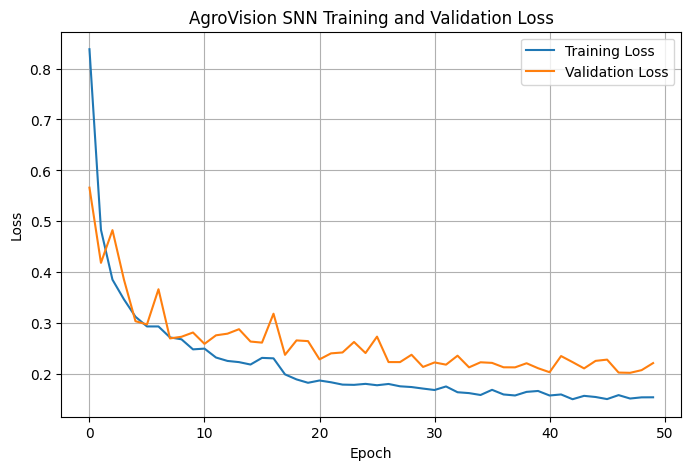

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AgroVision SNN Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

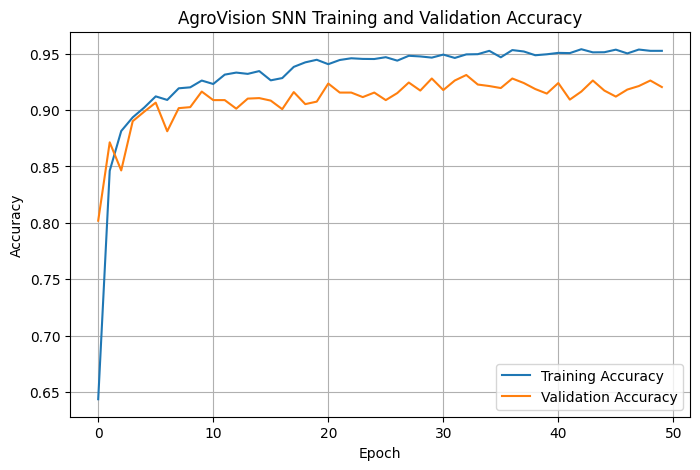

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("AgroVision SNN Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        spike_output = model(X_batch)

        output = spike_output.sum(dim=0)

        predictions = torch.argmax(
            output,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            y_batch.numpy()
        )

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("================================")
print("AGROVISION SNN TEST RESULTS")
print("================================")

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

AGROVISION SNN TEST RESULTS
Accuracy  : 0.9181
Precision : 0.9176
Recall    : 0.9181
F1 Score  : 0.9174


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.92      0.99      0.95       670
         Low       0.95      0.93      0.94      1037
    Moderate       0.84      0.81      0.83       540

    accuracy                           0.92      2247
   macro avg       0.91      0.91      0.91      2247
weighted avg       0.92      0.92      0.92      2247



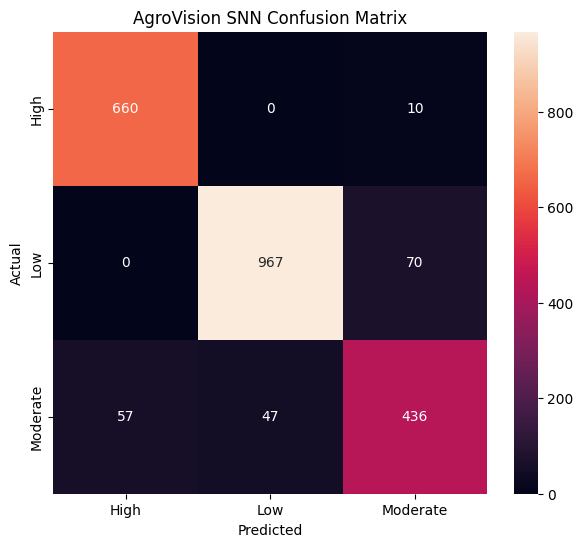

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AgroVision SNN Confusion Matrix")

plt.show()

In [ ]:
for i, class_name in enumerate(label_encoder.classes_):

    class_indices = np.array(all_labels) == i

    class_accuracy = np.mean(
        np.array(all_predictions)[class_indices] == i
    )

    print(
        f"{class_name}: "
        f"{class_accuracy * 100:.2f}%"
    )

High: 98.51%
Low: 93.25%
Moderate: 80.74%


In [ ]:
FINAL_MODEL_PATH = "agrovision_snn.pth"

torch.save(
    model.state_dict(),
    FINAL_MODEL_PATH
)

print("Model saved as:", FINAL_MODEL_PATH)

Model saved as: agrovision_snn.pth


In [ ]:
joblib.dump(
    scaler,
    "agrovision_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [ ]:
joblib.dump(
    label_encoder,
    "agrovision_label_encoder.pkl"
)

print("Label encoder saved.")

Label encoder saved.


In [ ]:
model_metadata = {
    "feature_columns": X_train.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "input_size": INPUT_SIZE,
    "classes": label_encoder.classes_.tolist()
}

joblib.dump(
    model_metadata,
    "agrovision_model_metadata.pkl"
)

print("Model metadata saved.")

Model metadata saved.


In [ ]:

files_to_package = [
    "agrovision_snn.pth",
    "agrovision_scaler.pkl",
    "agrovision_label_encoder.pkl",
    "agrovision_model_metadata.pkl"
]

with open("README.txt", "w") as f:

    f.write("""
AGROVISION COTTON ENVIRONMENTAL STRESS SNN
===========================================

Files:

1. agrovision_snn.pth
   Trained Spiking Neural Network.

2. agrovision_scaler.pkl
   Feature preprocessing scaler.

3. agrovision_label_encoder.pkl
   Converts model classes back to Low/Moderate/High.

4. agrovision_model_metadata.pkl
   Contains feature names and model configuration.

Target classes:
Low
Moderate
High

IMPORTANT:
The same preprocessing used during training must be used
when sending new data to the model.
""")

files_to_package.append("README.txt")

with open("agrovision_files.txt", "w") as f:
    f.writelines(file + "\n" for file in files_to_package)

print("Files prepared.")

Files prepared.


In [ ]:
import zipfile

zip_name = "AgroVision_SNN_Model.zip"

with zipfile.ZipFile(
    zip_name,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in files_to_package:
        zipf.write(file)

print("Created:", zip_name)

Created: AgroVision_SNN_Model.zip


In [ ]:
files.download(
    "AgroVision_SNN_Model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample_index = 0

sample = X_test_scaled[sample_index]

sample_tensor = torch.tensor(
    sample,
    dtype=torch.float32
).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    spike_output = model(
        sample_tensor
    )

    output = spike_output.sum(dim=0)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    prediction_index = torch.argmax(
        probabilities,
        dim=1
    ).item()

predicted_class = label_encoder.inverse_transform(
    [prediction_index]
)[0]

actual_class = label_encoder.inverse_transform(
    [y_test[sample_index]]
)[0]

print("Actual stress:", actual_class)
print("Predicted stress:", predicted_class)

print("\nClass probabilities:")

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities[0].cpu().numpy()
):

    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

Actual stress: High
Predicted stress: High

Class probabilities:
High: 99.98%
Low: 0.01%
Moderate: 0.01%


In [ ]:
def predict_stress_from_processed_data(
    feature_values
):

    feature_array = np.array(
        feature_values,
        dtype=np.float32
    ).reshape(1, -1)

    scaled = scaler.transform(
        feature_array
    )

    tensor = torch.tensor(
        scaled,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        spike_output = model(tensor)

        output = spike_output.sum(dim=0)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_index = torch.argmax(
            probabilities,
            dim=1
        ).item()

    predicted_label = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = probabilities[
        0,
        predicted_index
    ].item()

    return predicted_label, confidence

In [ ]:
print("MODEL INPUT FEATURES")
print("====================")

for i, feature in enumerate(X_train.columns):
    print(i, feature)

MODEL INPUT FEATURES
0 latitude
1 longitude
2 days_since_sowing
3 air_temperature_C
4 rainfall_mm
5 humidity_percent
6 soil_moisture
7 soil_nitrogen
8 soil_phosphorus
9 soil_potassium
10 NDVI
11 EVI
12 GNDVI
13 SIF_740
14 F687
15 F760
16 fluorescence_ratio
17 chlorophyll_content
18 leaf_area_index
19 year
20 month
21 light
22 AQI
23 ozone
24 time_index
25 date_day
26 date_month
27 date_year
28 growth_stage_Boll_Development
29 growth_stage_Flowering
30 growth_stage_Maturity
31 growth_stage_Sowing
32 growth_stage_Vegetative


In [ ]:
print("======================================")
print("       AGROVISION SNN MODEL")
print("======================================")

print("Input features :", INPUT_SIZE)
print("Output classes :", len(label_encoder.classes_))

print("\nClasses:")

for c in label_encoder.classes_:
    print("-", c)

print("\nTest Accuracy :", round(test_accuracy * 100, 2), "%")
print("Test Precision:", round(test_precision * 100, 2), "%")
print("Test Recall   :", round(test_recall * 100, 2), "%")
print("Test F1 Score :", round(test_f1 * 100, 2), "%")

print("\nModel file:")
print("agrovision_snn.pth")

       AGROVISION SNN MODEL
Input features : 33
Output classes : 3

Classes:
- High
- Low
- Moderate

Test Accuracy : 91.81 %
Test Precision: 91.76 %
Test Recall   : 91.81 %
Test F1 Score : 91.74 %

Model file:
agrovision_snn.pth
